



#**Rides Cancellation Analysis**
*   This project analyzes ride booking data to understand demand patterns, cancellations, pricing behavior, and customer experience.





In [ ]:
## Data Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel('/content/sample_data/ride_sharing_dataset.xlsx')
print (df.head())


   Ride_ID       Date      Time       City                Pickup         Drop  \
0        1 2025-11-04  20:36:02     Mumbai           Dharmavaram       Bokaro   
1        2 2026-01-22  20:17:23       Pune           Yamunanagar  Rajahmundry   
2        3 2026-01-30  01:21:41  Hyderabad              Mirzapur      Sambhal   
3        4 2025-10-04  09:58:28      Delhi  Kirari Suleman Nagar     Tirupati   
4        5 2026-01-12  08:06:13     Mumbai              Ludhiana      Bhiwani   

   Distance_km    Fare  Surge  Driver_Rating  Customer_Rating Ride_Status  \
0         5.17   56.87    NaN            2.5              3.7   Cancelled   
1         1.97   35.46    1.0            2.6              3.4   Completed   
2        10.38  249.12    1.2            3.1              3.5   Completed   
3        17.33  493.90    1.5            4.7              4.2   Completed   
4        15.86  285.48    1.0            2.6              4.6   Completed   

  Cancellation_Reason Payment Ride_Type  
0    Dri

In [ ]:
## Data Understanding
print(df.shape)
print(df.describe())
print(df.dtypes)
print(df.isnull().sum())


(1200, 15)
           Ride_ID                 Date  Distance_km         Fare  \
count  1200.000000                 1200  1140.000000  1140.000000   
mean    600.500000  2025-12-27 04:56:24    13.119746   261.452579   
min       1.000000  2025-09-28 00:00:00     1.010000    10.600000   
25%     300.750000  2025-11-10 00:00:00     6.947500   124.605000   
50%     600.500000  2025-12-28 00:00:00    13.385000   235.860000   
75%     900.250000  2026-02-11 00:00:00    19.190000   355.412500   
max    1200.000000  2026-03-29 00:00:00    24.950000  1120.500000   
std     346.554469                  NaN     6.958171   175.610483   

             Surge  Driver_Rating  Customer_Rating  
count  1140.000000    1088.000000      1094.000000  
mean      1.344912       3.725000         3.749269  
min       1.000000       2.500000         2.500000  
25%       1.000000       3.100000         3.100000  
50%       1.200000       3.700000         3.800000  
75%       1.500000       4.400000         4.40000

In [ ]:
## Handling Missing values.
## Handled missing values in distance, fare, and surge using median (to avoid outliers impact)
##Filled missing ratings using group-based logic (based on ride type)
##Replaced missing cancellation reasons with “Not Cancelled”

df['Cancellation_Reason']=df['Cancellation_Reason'].fillna("Not Cancelled")
df[['Distance_km','Fare','Surge']]=df[['Distance_km','Fare','Surge']].fillna(df[['Distance_km','Fare','Surge']].median())
df[['Driver_Rating','Customer_Rating']]=df[['Driver_Rating','Customer_Rating']].fillna(df.groupby('Ride_Type')[['Driver_Rating','Customer_Rating']].mean)
df['Ride_Status']=df['Ride_Status'].replace('No Driver','Cancelled')
print(df.isnull().sum())
print(df[['Driver_Rating','Customer_Rating']])

Ride_ID                0
Date                   0
Time                   0
City                   0
Pickup                 0
Drop                   0
Distance_km            0
Fare                   0
Surge                  0
Driver_Rating          0
Customer_Rating        0
Ride_Status            0
Cancellation_Reason    0
Payment                0
Ride_Type              0
dtype: int64
     Driver_Rating Customer_Rating
0              2.5             3.7
1              2.6             3.4
2              3.1             3.5
3              4.7             4.2
4              2.6             4.6
...            ...             ...
1195           4.2             4.7
1196           3.8             3.5
1197           3.1             3.2
1198           3.5             4.4
1199           2.5             3.3

[1200 rows x 2 columns]


## Demand Analysis

####City-Wise Ride Demand

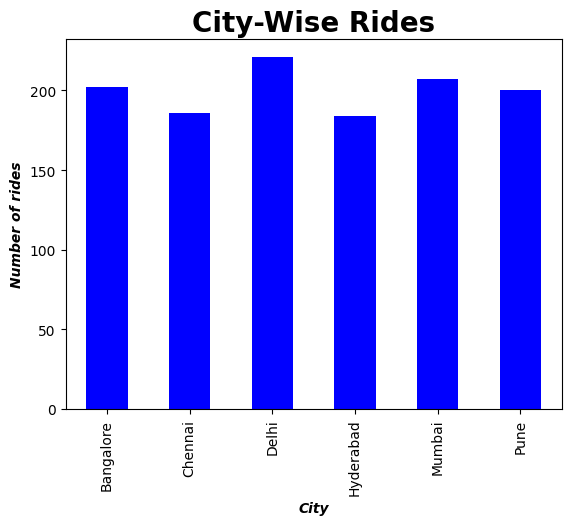

In [ ]:
City_rides=df.groupby('City')['Ride_ID'].count()
City_rides.plot(kind='bar',color='blue')
plt.title('City-Wise Rides',fontsize=20,fontweight='bold')
plt.xlabel('City',fontstyle='oblique',fontsize=10,fontweight='bold')
plt.ylabel('Number of rides',fontstyle='oblique',fontsize=10,fontweight='bold')
plt.show()



*   Delhi dominates ride demand across all
cities, indicating it as the primary market with the highest user activity and revenue potential.
*   Hyderabad records the lowest ride demand, suggesting comparatively weaker market penetration or lower user engagement.









###Hour-Wise Ride demand

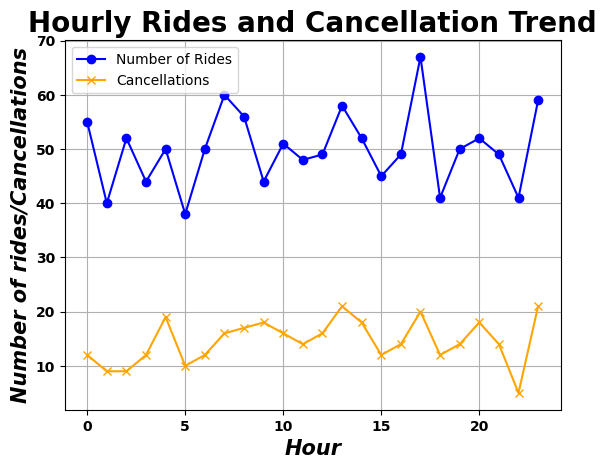

In [ ]:
df['Hour']=pd.to_datetime(df['Time'],format='%H:%M:%S' ).dt.hour
Hours_trend=df.groupby('Hour')['Ride_ID'].count()
cancelled=df[df['Ride_Status']=='Cancelled']
Hourly_cancellation=cancelled.groupby('Hour')['Ride_Status'].count()
Hours_trend.plot(marker='o',color='blue',label='Number of Rides')
Hourly_cancellation.plot(marker='x',color='orange',label='Cancellations')
plt.xlabel('Hour',fontstyle='oblique',fontsize=15,fontweight='bold')
plt.ylabel('Number of rides/Cancellations',fontstyle='oblique',fontsize=15,fontweight='bold')
plt.title('Hourly Rides and Cancellation Trend',fontsize=20,fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend()
plt.grid()
plt.show()



*   Ride demand peaks at around 5 PM (67 rides), confirming strong evening commute demand, while the lowest demand is observed around 5 AM (38 rides), indicating minimal early-morning activity.



*   Cancellations spike at 2 PM and 11 PM (21 cancellations), while dropping to a low around 10 PM (5 cancellations), suggesting inconsistent supply-demand balance during specific hours.





##Cancellation Analysis

##City-Wise Cancellations

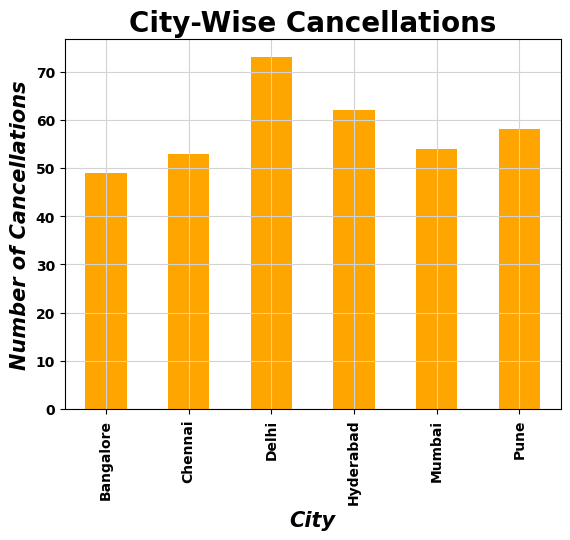

In [ ]:
City_cancellation=df[df['Ride_Status']=='Cancelled'].groupby('City')['Ride_Status'].count()
City_cancellation.plot(kind='bar',color='Orange')
plt.xlabel('City',fontstyle='oblique',fontsize=15,fontweight='bold')
plt.ylabel('Number of Cancellations',fontstyle='oblique',fontsize=15,fontweight='bold')
plt.title('City-Wise Cancellations',fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(color='lightgrey')
plt.show()




*   Delhi records the highest number of cancellations, indicating a potential supply–demand imbalance in a high-demand market.

*  Bangalore shows the lowest cancellations among all cities, suggesting relatively stable operations and better supply-demand alignment



##Mode wise Cancellations

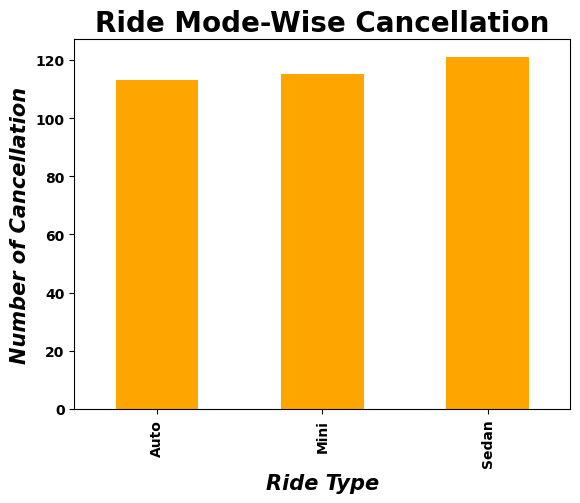

In [ ]:
mode_cancellation=df[df['Ride_Status']=='Cancelled'].groupby('Ride_Type')['Ride_Status'].count()
mode_cancellation.plot(kind='bar',color='Orange')
plt.xlabel('Ride Type',fontstyle='italic',fontsize=15,fontweight='bold')
plt.ylabel('Number of Cancellation',fontstyle='italic',fontsize=15,fontweight='bold')
plt.title('Ride Mode-Wise Cancellation',fontweight='bold',fontsize=20)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()



*   Cancellations across ride types (Auto, Mini, Sedan) are relatively close in volume, suggesting that cancellation issues are consistent across categories rather than being isolated to a single segment.




##Operations Analysis

####Cancellaton rate by City

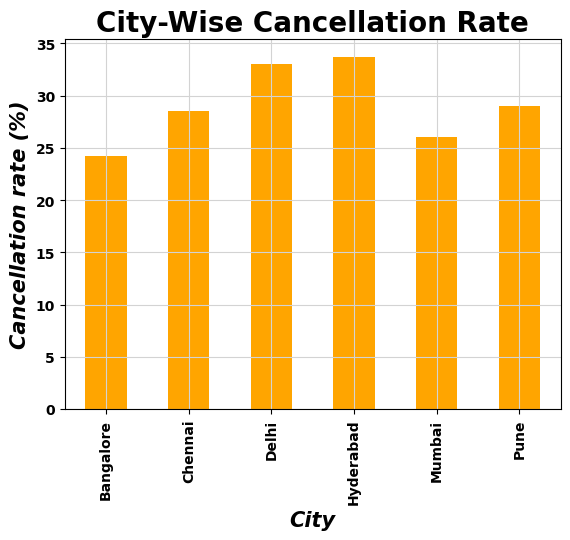

In [ ]:
df['Cancelled']=np.where(df['Ride_Status']=='Cancelled',1,0)
City_Cancellation_rate=df.groupby('City')['Cancelled'].mean()*100
City_Cancellation_rate.plot(kind='bar',color='orange')
plt.xlabel('City',fontstyle='italic',fontsize=15,fontweight='bold')
plt.ylabel('Cancellation rate (%)',fontstyle='italic',fontsize=15,fontweight='bold')
plt.title('City-Wise Cancellation Rate',fontsize=20,fontweight='bold')
plt.grid(color='lightgrey')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.show()



*   Hyderabad records the highest cancellation rate among all cities, indicating greater ride fulfillment challenges.


*   Bangalore shows the lowest cancellation rate, suggesting more efficient ride completion and better operational stability.






####Cancellation rate by hour

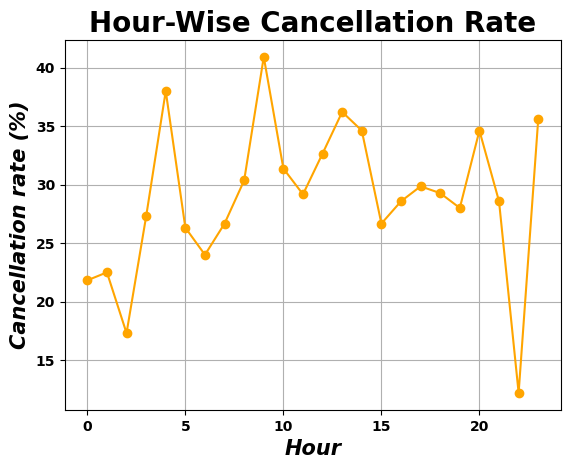

In [ ]:
Hour_cancellation_rate=df.groupby('Hour')['Cancelled'].mean()*100
Hour_cancellation_rate.plot(marker='o',color='orange')
plt.xlabel('Hour',fontstyle='italic',fontsize=15,fontweight='bold')
plt.ylabel('Cancellation rate (%)',fontstyle='italic',fontsize=15,fontweight='bold')
plt.title('Hour-Wise Cancellation Rate',fontsize=20,fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid()
plt.show()



*   Cancellation rates peak around typical work start hours (9:00 AM), indicating increased pressure on ride availability during morning commute periods.
*   Higher cancellation rates during early morning (4:00 AM) and late evening (11:00 PM) hours suggest limited driver availability during off-peak operational periods.



##Key Observations



*  Hyderabad records the lowest ride demand but a disproportionately high cancellation rate, indicating a significant supply–demand imbalance, likely driven by limited driver availability.

*  High cancellation rates at 9:00 AM, even with moderate demand, highlight operational inefficiencies in meeting morning ride requirements.


##Recommendations



*  Improve driver availability during peak hours (e.g., morning and evening commute periods) to better match high demand and reduce cancellations.

*   Introduce targeted incentives for late evening and early morning rides to encourage driver participation during low-supply periods.

*   Enhance driver allocation strategies in Hyderabad to address high cancellation rates and improve ride fulfillment efficiency.





